In [ ]:
!pip show matplotlib seaborn scikit-learn tensorflow
# !pip install tensorflow numpy matplotlib seaborn scikit-learn --quiet

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')

TensorFlow version: 2.20.0
GPUs available: 2


In [ ]:
results_dir = "results/DogsVwolves/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

In [ ]:
!nvidia-smi
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'\nGPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('\nNo GPU found — training will run on CPU (slower).')

Sat Jul 25 17:21:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             32W /   70W |    7229MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
from pathlib import Path

# 1. Path Identification (Applying Step 5 principles)
kaggle_input_path = "/kaggle/input/datasets/harishvutukuri/dogs-vs-wolves/data"
base_path = Path(kaggle_input_path)

print(f"Checking Base Directory: {base_path}")
print("-" * 50)

# 2. Directory Exploration and Data Verification
if base_path.exists():
    for class_folder in os.listdir(base_path):
        folder_path = base_path / class_folder

        if folder_path.is_dir():
            # Data Cleaning Principle: explicitly count only valid image formats
            jpg_count = len(list(folder_path.glob('*.jpg')))
            png_count = len(list(folder_path.glob('*.png')))
            jpeg_count = len(list(folder_path.glob('*.jpeg')))
            total_images = jpg_count + png_count + jpeg_count

            print(f"Class Folder Detected : '{class_folder}'")
            print(f" -> Valid Images Found: {total_images}")
            print("-" * 50)
else:
    print("Path does not exist! Please check the Kaggle input directory.")

Checking Base Directory: /kaggle/input/datasets/harishvutukuri/dogs-vs-wolves/data
--------------------------------------------------
Class Folder Detected : 'wolves'
 -> Valid Images Found: 1000
--------------------------------------------------
Class Folder Detected : 'dogs'
 -> Valid Images Found: 1000
--------------------------------------------------


In [ ]:
# Set the base directory to your verified Kaggle path
BASE_DIR = Path('/kaggle/input/datasets/harishvutukuri/dogs-vs-wolves/data')

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3
SEED = 42 # Added to ensure reproducibility during the split

print(f'Image size : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS}')
print(f'Learning rate: {LR}')
print("-" * 50)

Image size : 128 x 128
Batch size : 64
Max epochs : 50
Learning rate: 0.001
--------------------------------------------------


In [ ]:
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

print("\nLoading Validation/Test Data:")
val_and_test_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

# Determine how many batches make up the 20%
val_batches = tf.data.experimental.cardinality(val_and_test_dataset)

# Create the Validation Dataset (First half of the 20%)
val_dataset = val_and_test_dataset.take(val_batches // 2)

# Create the Test Dataset (Second half of the 20%)
test_dataset = val_and_test_dataset.skip(val_batches // 2)

print(f"\nSuccessfully created 3 splits:")
print(f" - Validation batches: {tf.data.experimental.cardinality(val_dataset).numpy()}")
print(f" - Test batches: {tf.data.experimental.cardinality(test_dataset).numpy()}")

# Get class names and number of classes
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'\nClasses ({num_classes}): {class_names}')

Loading Training Data:
Found 2000 files belonging to 2 classes.
Using 1600 files for training.

Loading Validation/Test Data:
Found 2000 files belonging to 2 classes.
Using 400 files for validation.

Successfully created 3 splits:
 - Validation batches: 3
 - Test batches: 4

Classes (2): ['dogs', 'wolves']


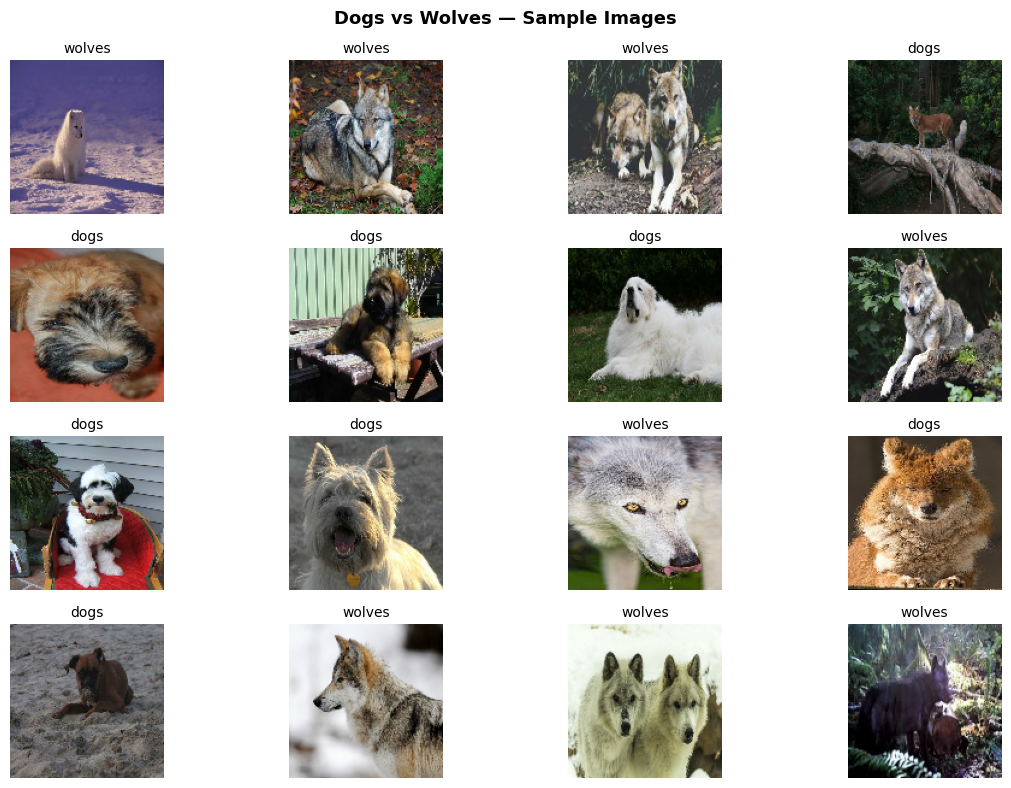

In [ ]:
# STEP 14: Sanity-Check (visualise dataset samples).
# Capture one fixed batch so the visualisation is stable across re-runs
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

# STEP 15: Visualise the first 16 images and their labels
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')

plt.suptitle('Dogs vs Wolves — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{results_dir}lab8_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# STEP 16: Optimise the data pipeline. Using .cache(), .shuffle(), and .prefetch() creates an asynchronous pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)
print('\nPipeline optimised with cache + shuffle + prefetch.')


Pipeline optimised with cache + shuffle + prefetch.


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

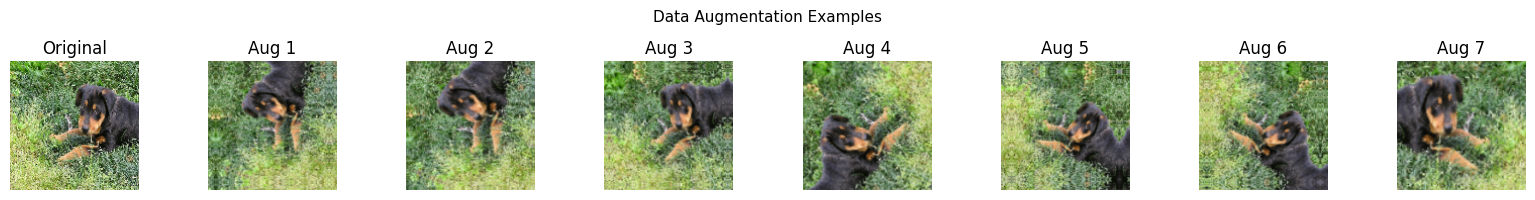

In [ ]:
for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig(f'{results_dir}lab8_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
import os
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

models_dir = "/kaggle/working/models/"
os.makedirs(models_dir, exist_ok=True)

def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'{models_dir}{name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{results_dir}lab8_{title.lower().replace(" ", "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model'):
    """Evaluate a multiclass classification model."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # multiclass prediction (softmax -> argmax)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f"\n{title}")
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))

    # Fixed the missing comma and fmt bug from the manual here
    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='d',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 12, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{results_dir}lab8_{title.lower().replace(" ", "_")}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)

print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


In [ ]:
import tensorflow as tf

def build_custom_cnn(input_shape, augmentation):
    inputs = tf.keras.Input(shape=input_shape)

    x = augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)


    BN_MOMENTUM = 0.85

    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x) # Safe here at the end of the pipeline

    # Binary output
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='custom_cnn_completely_fixed')

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)

# Display the architecture
cnn_model.summary()

#  Compile the model
print("\nCompiling Fixed Custom CNN...")
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# Train the model
print("\nStarting Training for Fixed Custom CNN...")
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn_completely_fixed'),
    verbose=1
)

Model: "custom_cnn_completely_fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)


Compiling Fixed Custom CNN...

Starting Training for Fixed Custom CNN...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.6000 - loss: 0.7209 - val_accuracy: 0.6458 - val_loss: 0.6465 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.6856 - loss: 0.5955 - val_accuracy: 0.7240 - val_loss: 0.5582 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.7200 - loss: 0.5535 - val_accuracy: 0.4844 - val_loss: 0.9573 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.7269 - loss: 0.5406 - val_accuracy: 0.8125 - val_loss: 0.4461 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.7606 - loss: 0.5180 - val_accuracy: 0.6667 - val_loss: 0.6441 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.7575 - loss: 0.4992 - val_accuracy: 0.8021 - val_loss: 0.4380 - learning_rate: 0.0010
Epoch 7/50
25

Custom CNN -> val_loss: 0.3608
val_accuracy: 0.8542

Generating Learning Curves...


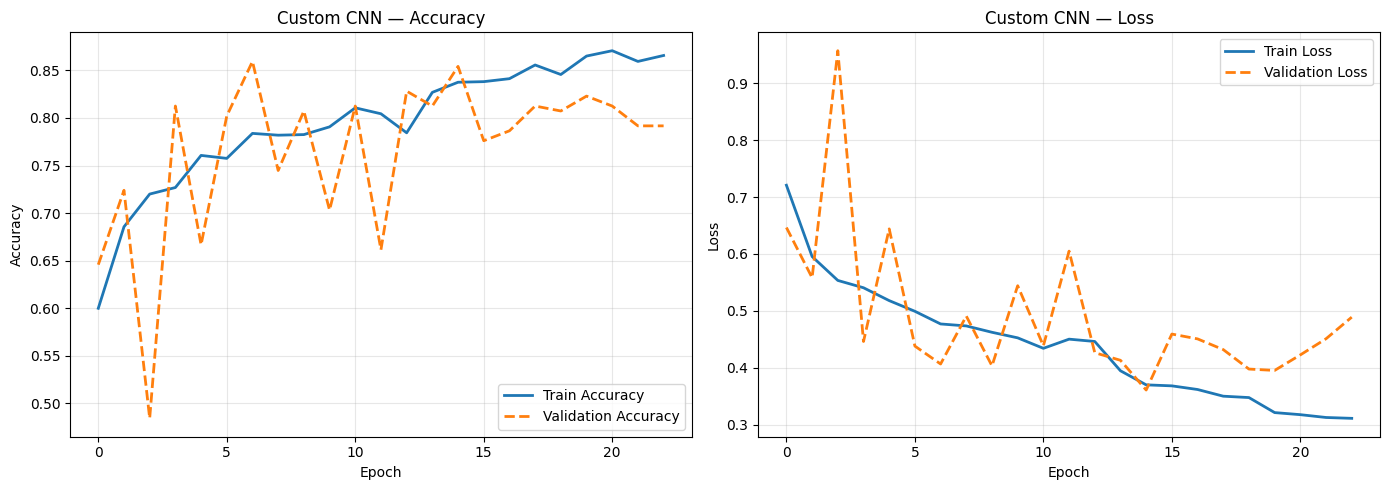


Evaluating Custom CNN on Test Dataset...

Custom CNN
Accuracy  : 0.8413
Precision : 0.8606
Recall    : 0.8413
F1-Score  : 0.8404

Classification Report:
              precision    recall  f1-score   support

        dogs     0.7686    0.9490    0.8493        98
      wolves     0.9425    0.7455    0.8325       110

    accuracy                         0.8413       208
   macro avg     0.8556    0.8472    0.8409       208
weighted avg     0.8606    0.8413    0.8404       208



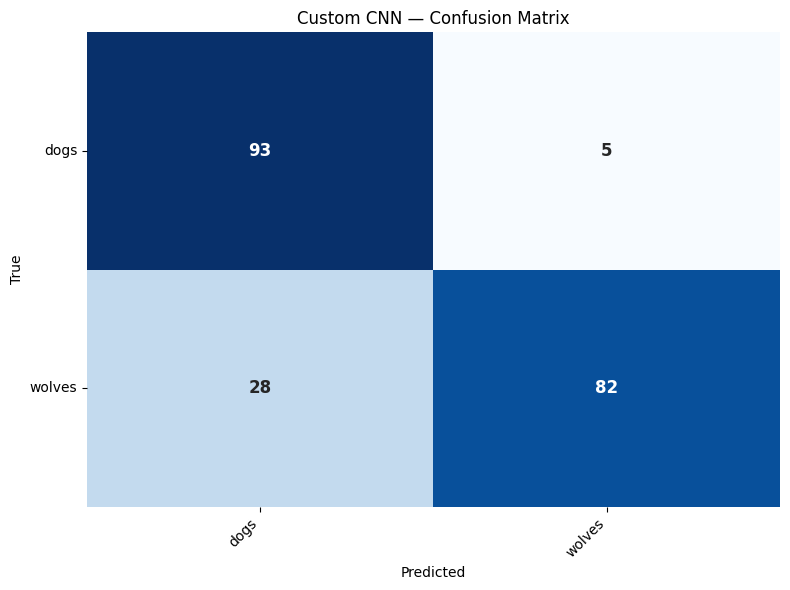

In [ ]:
# STEP 23: Evaluate the Custom CNN using loss and accuracy on the validation set
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

# STEP 24: Visualise the Learning curves
print("\nGenerating Learning Curves...")
plot_learning_curves(cnn_history, 'Custom CNN')

# STEP 25: Evaluate the custom CNN model on the test data
print("\nEvaluating Custom CNN on Test Dataset...")
cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')

In [ ]:
# import tensorflow as tf

# STEP 26: Build the Transfer Learning Model (MobileNetV3Small)
def build_transfer_model(input_shape, augmentation, backbone='mobilenetv3small'):
    """
    Feature extraction model:
    1. Augment input (training only)
    2. Preprocess for MobileNetV3 (scales to [-1, 1])
    3. Frozen MobileNetV3Small backbone (no top)
    4. GlobalAveragePooling2D
    5. Dense classification head
    """
    if backbone == 'mobilenetv3small':
        base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name = 'mobilenetv3small_transfer'
    else:
        # Fallback: MobileNetV2
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name = 'mobilenetv2_transfer'

    # Freeze all base layers for feature extraction (no training)
    base_model.trainable = False
    print(f'Base model      : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')

    # Build the model graph
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x) # scale pixels to [-1, 1]

    # frozen inference mode
    x = base_model(x, training=False)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Binary output: using num_classes to assign probabilities
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name=model_name), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation, backbone='mobilenetv3small')
tl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Base model      : MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
# STEP 27: Compile and train the model (feature extraction phase).
# We use a very small learning rate (1e-4) to avoid accidentally
TL_LR = 1e-4

print("\nCompiling Transfer Learning Model...")
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print("\nStarting Feature Extraction Training...")
tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('tl_feature_extraction'),
    verbose=1,
)


Compiling Transfer Learning Model...

Starting Feature Extraction Training...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.6119 - loss: 0.7156 - val_accuracy: 0.8854 - val_loss: 0.3808 - learning_rate: 1.0000e-04
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8213 - loss: 0.4008 - val_accuracy: 0.9271 - val_loss: 0.2429 - learning_rate: 1.0000e-04
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8725 - loss: 0.3099 - val_accuracy: 0.9375 - val_loss: 0.2071 - learning_rate: 1.0000e-04
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8813 - loss: 0.2837 - val_accuracy: 0.9531 - val_loss: 0.1760 - learning_rate: 1.0000e-04
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8813 - loss: 0.2847 - val_accuracy: 0.9375 - val_loss: 0.1833 - learning_rate: 1.0000e-04
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8956 - loss: 0.2468 - val_accuracy: 0.9583 - val_loss: 0.1565 - learning_rate: 1.

MobileNetV3 TL -> val_loss: 0.1166
MobileNetV3 TL -> val_accuracy: 0.9688

Generating Learning Curves...


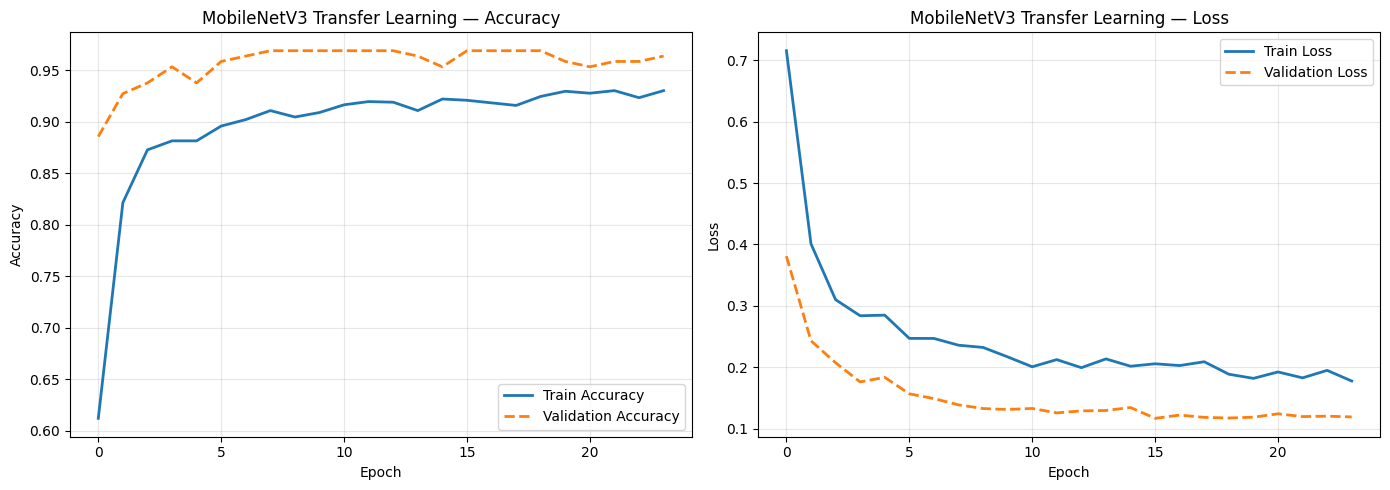


Evaluating MobileNetV3 TL on Test Dataset...

MobileNetV3 Transfer Learning
Accuracy  : 0.9519
Precision : 0.9527
Recall    : 0.9519
F1-Score  : 0.9520

Classification Report:
              precision    recall  f1-score   support

        dogs     0.9314    0.9694    0.9500        98
      wolves     0.9717    0.9364    0.9537       110

    accuracy                         0.9519       208
   macro avg     0.9515    0.9529    0.9519       208
weighted avg     0.9527    0.9519    0.9520       208



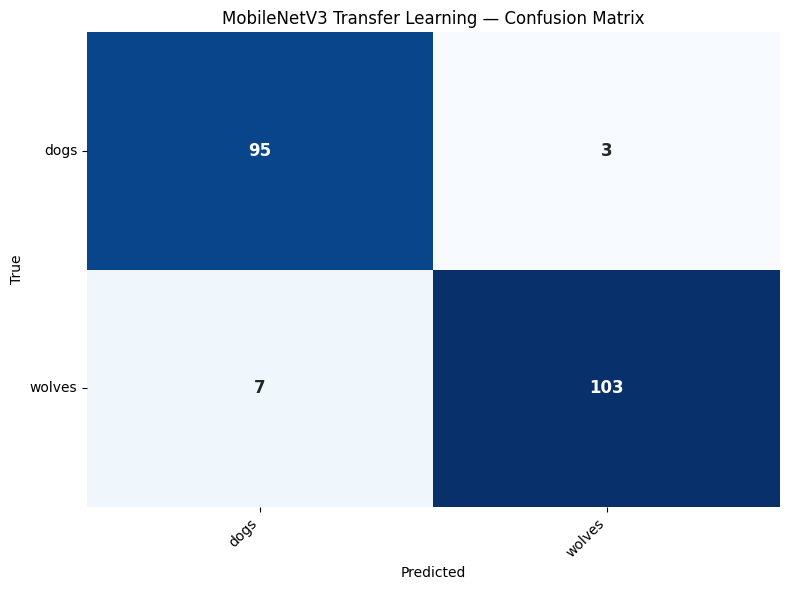

In [ ]:
# STEP 28: Evaluate the Transfer Learning Model on the validation set
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')

# Visualise the Learning curves
print("\nGenerating Learning Curves...")
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evaluate the model on the unseen test data
print("\nEvaluating MobileNetV3 TL on Test Dataset...")
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV3 Transfer Learning')

In [ ]:
# STEP 30: Fine-Tuning (unfreeze top layers).
# After the classification head has converged, we can unfreeze the top layers
# of the backbone and continue training at a very low learning rate.
# This lets the pre-trained features adapt slightly to the Dogs vs Wolves domain.

print("Unfreezing the top 30 layers of the base model...")
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

Unfreezing the top 30 layers of the base model...
Trainable base layers after unfreezing: 30 / 157


In [ ]:
# STEP 31: Recompile with a 10x smaller learning rate
FINETUNE_LR = TL_LR / 10

print(f"Recompiling with Fine-Tuning Learning Rate: {FINETUNE_LR}")
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

Recompiling with Fine-Tuning Learning Rate: 1e-05


In [ ]:
# STEP 32: Continue training (fine-tuning phase).
# We continue training with the same callbacks.
# The best model will be saved as 'tl_finetuned.keras'.
print("\nStarting Fine-Tuning Training Phase...")
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=make_callbacks('tl_finetuned'),
    verbose=2,
)


Starting Fine-Tuning Training Phase...
Epoch 1/20
25/25 - 11s - 445ms/step - accuracy: 0.8475 - loss: 0.3761 - val_accuracy: 0.9583 - val_loss: 0.1213 - learning_rate: 1.0000e-05
Epoch 2/20
25/25 - 1s - 34ms/step - accuracy: 0.8700 - loss: 0.2974 - val_accuracy: 0.9479 - val_loss: 0.1356 - learning_rate: 1.0000e-05
Epoch 3/20
25/25 - 1s - 30ms/step - accuracy: 0.8687 - loss: 0.2914 - val_accuracy: 0.9479 - val_loss: 0.1435 - learning_rate: 1.0000e-05
Epoch 4/20
25/25 - 1s - 31ms/step - accuracy: 0.8819 - loss: 0.2970 - val_accuracy: 0.9427 - val_loss: 0.1514 - learning_rate: 1.0000e-05
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
25/25 - 1s - 30ms/step - accuracy: 0.8881 - loss: 0.2623 - val_accuracy: 0.9427 - val_loss: 0.1504 - learning_rate: 1.0000e-05
Epoch 6/20
25/25 - 1s - 30ms/step - accuracy: 0.8869 - loss: 0.2650 - val_accuracy: 0.9427 - val_loss: 0.1481 - learning_rate: 3.0000e-06
Epoch 7/20
25/25 - 1s - 31ms/step - accuracy: 0.8963

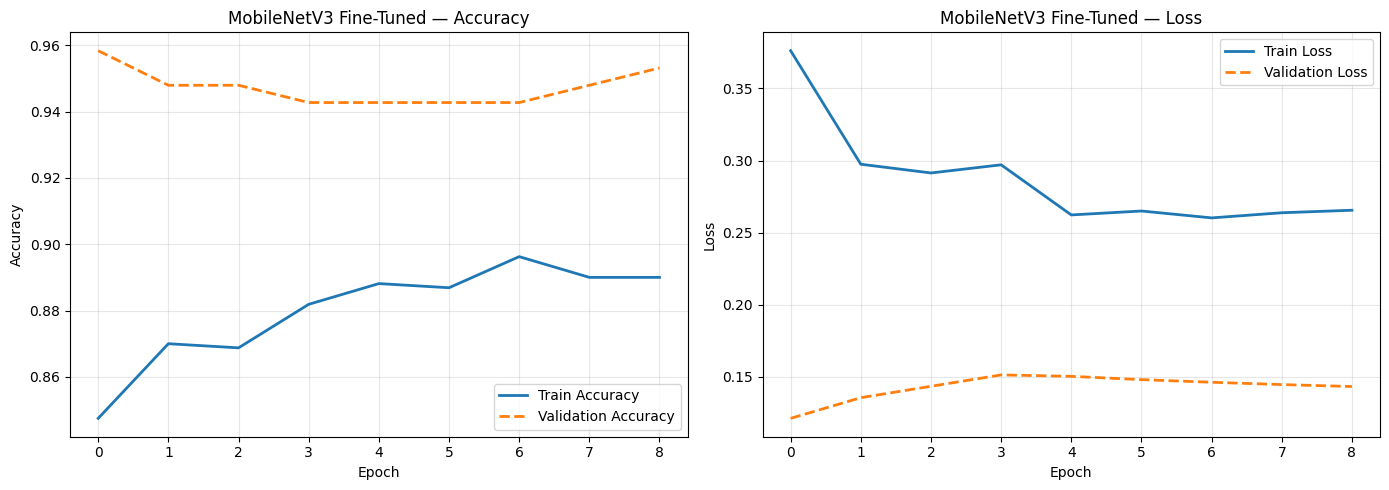

In [ ]:
# STEP 33: Visualise fine-tuning learning curves.
# We expect to see a small boost in performance as the pre-trained features adapt to the new domain.
# However, if the dataset is small, the improvement may be marginal and could even lead to overfitting if not done carefully.
plot_learning_curves(ft_history, 'MobileNetV3 Fine-Tuned')


Evaluating Fine-Tuned MobileNetV3 on Test Dataset...

MobileNetV3 Fine-Tuned
Accuracy  : 0.9471
Precision : 0.9471
Recall    : 0.9471
F1-Score  : 0.9471

Classification Report:
              precision    recall  f1-score   support

        dogs     0.9485    0.9388    0.9436        98
      wolves     0.9459    0.9545    0.9502       110

    accuracy                         0.9471       208
   macro avg     0.9472    0.9467    0.9469       208
weighted avg     0.9471    0.9471    0.9471       208



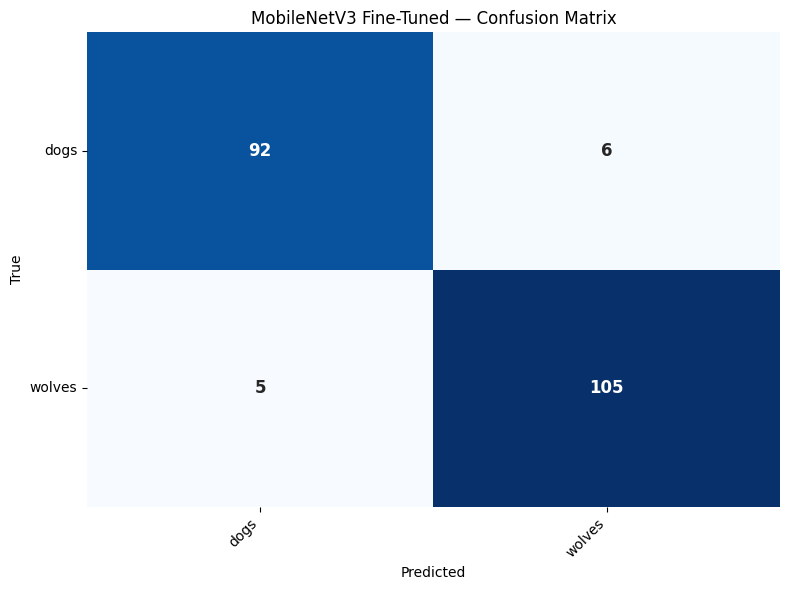

In [ ]:
# STEP 34: Evaluate the fine-tuned model on the test set.
# We expect to see a small boost in performance compared to the feature extraction phase,
# but the improvement may be marginal if the dataset is small or if overfitting occurs.

print("\nEvaluating Fine-Tuned MobileNetV3 on Test Dataset...")
ft_test_acc = evaluate_model(
    tl_model,
    test_dataset,
    class_names,
    'MobileNetV3 Fine-Tuned'
)

In [ ]:
# STEP 35: Side-by-side model comparison.
# Compare all three models on test accuracy and parameter count.
results = {
    'Custom CNN': {
        'acc': cnn_test_acc,
        'params': cnn_model.count_params()
    },
    'MobileNetV3 (TL)': {
        'acc': tl_test_acc,
        'params': tl_model.count_params()
    },
    'MobileNetV3 (FT)': {
        'acc': ft_test_acc,
        'params': tl_model.count_params()
    }
}

print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    0.8413        322,338
MobileNetV3 (TL)              0.9519      1,087,346
MobileNetV3 (FT)              0.9471      1,087,346


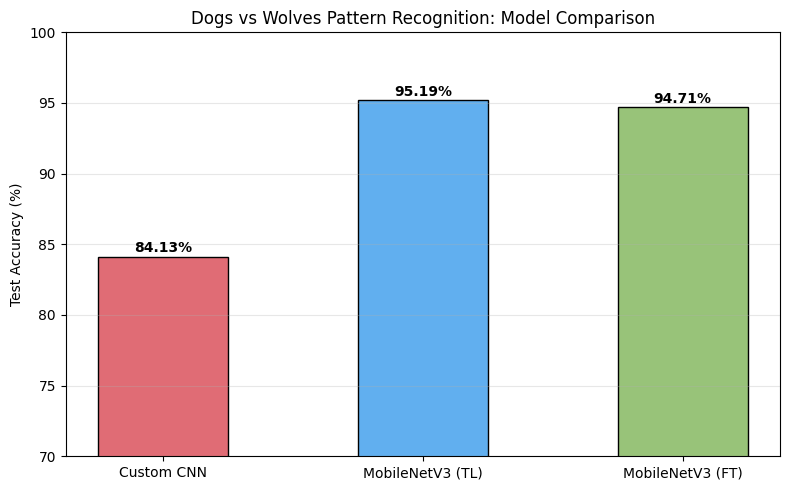

In [ ]:
# import matplotlib.pyplot as plt

# STEP 36: Visualise model comparison.

labels = list(results.keys())
accs = [v['acc'] * 100 for v in results.values()]

colors = ['#e06c75', '#61afef', '#98c379']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)

ax.set_ylim(70, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Dogs vs Wolves Pattern Recognition: Model Comparison')
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{acc:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('lab8_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# STEP 37: Predict on a new image.
# Load any .jpg image from disk, resize it to 128x128 (fixed from 224x224),
# and classify with both models.
def predict_image(img_path, models_dict, class_names, image_size=(128, 128)):
    """Load an image file and classify it with each model in models_dict."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)

    # Scale to [0, 255] float32 (assuming model handles scaling, or scale to [0, 1] if needed)
    img_array = np.expand_dims(img_array, axis=0) # (1, H, W, 3)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        # Handle predictions (assumes models output a single probability or a softmax array)
        preds = mdl.predict(img_array, verbose=0)[0]

        # If the output is a single node (binary), use preds[0]. If it's an array of 2 (softmax), use argmax.
        if len(preds) == 1:
            prob = preds[0]
            label = class_names[int(prob >= 0.5)]
        else:
            prob = np.max(preds)
            label = class_names[np.argmax(preds)]

        print(f'{name:<25}: {label} (confidence={prob:.4f})')




In [ ]:
# STEP 38: Uncomment the predict_image() call below and supply a real image path to test.
test_image_path = 'path/to/your/image.jpg'

try:
    predict_image(
        test_image_path,
        {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},
        class_names
    )
except FileNotFoundError:
    print(f"Waiting for you to update the image path! Could not find: {test_image_path}")




Waiting for you to update the image path! Could not find: path/to/your/image.jpg


In [ ]:
# STEP 39: Save Both Models to the correct directory

results_dir = "results/DogsVwolves/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

# Save the models using the results_dir variable
cnn_model.save(f'{results_dir}custom_cnn.keras')
tl_model.save(f'{results_dir}mobilenetv3_transfer.keras')

print(f'Models saved successfully to the {results_dir} folder:')
print(f' -> {results_dir}custom_cnn.keras')
print(f' -> {results_dir}mobilenetv3_transfer.keras')

Models saved successfully to the results/DogsVwolves/ folder:
 -> results/DogsVwolves/custom_cnn.keras
 -> results/DogsVwolves/mobilenetv3_transfer.keras


In [ ]:
%%writefile app.py
# STEP 1: Import Required Libraries
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image
import base64
from io import BytesIO

# STEP 2: Page config
st.set_page_config(
    page_title="Dog vs Wolf Classifier",
    page_icon="https://cdn-icons-png.flaticon.com/128/17839/17839240.png",
    layout="centered",
)

# STEP 3: Techy custom CSS (structure/layout only)
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;600&family=JetBrains+Mono:wght@400;500&display=swap');

html, body, [class*="css"]  {
    font-family: 'Space Grotesk', sans-serif;
}

.hero {
    text-align: center;
    padding: 1.5rem 0 1rem 0;
}
.hero h1 {
    font-size: 2.1rem;
    font-weight: 600;
    margin-bottom: 0.3rem;
}
.hero p {
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.85rem;
    letter-spacing: 0.02em;
    opacity: 0.7;
}

.card {
    border: 1px solid rgba(128,128,128,0.25);
    border-radius: 16px;
    padding: 1.4rem;
    margin-bottom: 1.2rem;
}

[data-testid="stFileUploaderDropzone"] {
    border-radius: 14px;
}

/* FIXED BUTTON CSS */
div[data-testid="stButton"] {
    display: flex;
    justify-content: center;
    width: 100%;
}
div[data-testid="stButton"] button {
    width: 100% !important;
    max-width: 400px !important;
    min-height: 52px !important;
    font-weight: 600 !important;
    font-size: 1.05rem !important;
    border-radius: 10px !important;
    padding: 0.85rem 2rem !important; /* Fixed padding: Top/Bottom 0.85rem, Left/Right 2rem */
    transition: transform 0.15s ease !important;
}
div[data-testid="stButton"] button:hover {
    transform: scale(1.02) !important;
}
div[data-testid="stButton"] button:active {
    transform: scale(0.98) !important;
}

.result-badge {
    font-family: 'JetBrains Mono', monospace;
    font-size: 1.6rem;
    font-weight: 600;
    text-align: center;
    padding: 0.6rem;
    border-radius: 12px;
    border: 1px solid rgba(128,128,128,0.3);
    margin-bottom: 1rem;
}

.centered-img {
    display: flex;
    justify-content: center;
    margin-bottom: 1rem;
}
</style>
""", unsafe_allow_html=True)

# STEP 4: Load model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model(
        "/kaggle/working/results/DogsVwolves/mobilenetv3_transfer.keras"
    )
    return model

# STEP 5: Prediction function
def predict(model, pil_image):
    img = pil_image.convert("RGB").resize((128, 128))
    arr = np.expand_dims(np.array(img, dtype=np.float32), axis=0)
    preds = model.predict(arr, verbose=0)[0]
    prob_dog = float(preds[0])
    prob_wolf = float(preds[1])
    label = "Dog" if prob_dog >= prob_wolf else "Wolf"
    return label, prob_wolf * 100, prob_dog * 100

# STEP 6: Hero / welcome section
st.markdown("""
<div class="hero">
    <h1>Dog vs Wolf Classifier</h1>
    <p>GET-324 · TRANSFER LEARNING · Predictive AI Model</p>
</div>
""", unsafe_allow_html=True)

st.markdown("""
<div class="card">
This app uses a fine-tuned <b>MobileNetV3</b> convolutional neural network
to tell the difference between dogs and wolves from a single image.
Drop a photo below, hit <b>Predict</b>, and the model will return its verdict
with confidence scores for each class.
</div>
""", unsafe_allow_html=True)

model = load_model()

if "last_file_id" not in st.session_state:
    st.session_state.last_file_id = None
if "result" not in st.session_state:
    st.session_state.result = None

uploaded_file = st.file_uploader("Drop a dog or wolf image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None and uploaded_file.file_id != st.session_state.last_file_id:
    st.session_state.last_file_id = uploaded_file.file_id
    st.session_state.result = None

if uploaded_file:
    img = Image.open(uploaded_file)

    buf = BytesIO()
    img.convert("RGB").save(buf, format="PNG")
    b64_img = base64.b64encode(buf.getvalue()).decode()
    st.markdown(
        f'<div class="centered-img"><img src="data:image/png;base64,{b64_img}" width="320" style="border-radius:12px;"></div>',
        unsafe_allow_html=True,
    )

    if st.button("Predict", type="primary", use_container_width=True):
        with st.spinner("Analyzing image..."):
            label, wolf_pct, dog_pct = predict(model, img)
            st.session_state.result = (label, wolf_pct, dog_pct)

    if st.session_state.result:
        label, wolf_pct, dog_pct = st.session_state.result
        badge_class = "badge-wolf" if label == "Wolf" else "badge-dog"
        st.markdown(
            f'<div class="result-badge {badge_class}">Prediction: {label}</div>',
            unsafe_allow_html=True,
        )
        st.progress(int(dog_pct), text=f"Dog: {dog_pct:.1f}%")
        st.progress(int(wolf_pct), text=f"Wolf: {wolf_pct:.1f}%")
else:
    st.session_state.result = None

Overwriting app.py


In [ ]:
!pip install -q streamlit
!npm install localtunnel

⠙⠹⠸⠼⠴⠦
up to date, audited 23 packages in 841ms
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦

In [ ]:
!curl ipv4.icanhazip.com

34.26.200.15


In [ ]:
import os
import time
import subprocess

# 1. Kill any old crashed servers to ensure a clean slate
os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")
time.sleep(2) # Wait 2 seconds for ports to clear

#  Re-Download the Cloudflare Tunnel tool (This fixes the error!)
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

# 2. Launch Streamlit explicitly as a headless background server
print("Starting Streamlit server...")
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.address", "0.0.0.0",
    "--server.headless", "true"
])

# Give Streamlit 5 seconds to fully wake up before opening the tunnel
time.sleep(5)

# 3. Start the Cloudflare Tunnel!
print("Opening Cloudflare tunnel...")
!./cloudflared tunnel --url http://localhost:8501

Starting Streamlit server...




2026-07-25 17:31:40.240 Uvicorn server started on 0.0.0.0:8501



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://34.26.200.15:8501

Opening Cloudflare tunnel...
2026-07-25T17:31:43Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-25T17:31:43Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-25T17:31:47Z INF +--------------------------------------------------------------------------------------------+


I0000 00:00:1785000736.593569    3448 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6530 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785000736.595846    3448 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  Stopping...
^C
2026-07-25T17:34:06Z INF Initiating graceful shutdown due to signal interrupt ...
2026-07-25T17:34:06Z ERR failed to run the datagram handler error="Application error 0x0 (remote)" connIndex=0 event=0 ip=198.41.200.113
2026-07-25T17:34:06Z ERR failed to serve tunnel connection error="accept stream listener encountered a failure while serving" connIndex=0 event=0 ip=198.41.200.113
2026-07-25T17:34:06Z ERR Serve tunnel error error="accept stream listener encountered a failure while serving" connIndex=0 event=0 ip=198.41.200.113
2026-07-25T17:34:06Z INF Retrying connection in up to 1s connIndex=0 event=0 ip=198.41.200.113
2026-07-25T17:34:06Z ERR Connection terminated connIndex=0
2026-07-25T17:34:06Z ERR no more connections active and exiting
2026-07-25T17:34:06Z INF Tunnel server stopped
2026-07-25T17:34:06Z INF Metrics server stopped


In [ ]:
%%writefile requirements.txt
streamlit==1.36.0
tensorflow-cpu==2.15.0
numpy==1.26.4
pillow==10.3.0

Writing requirements.txt
